# NB09 — Win Probability: BCE vs MSE Experiment (M2)

**Problem (M2):** Win prob model (NB03) is overconfident at extremes — at 6 wickets down needing 80+ off remaining balls, it outputs ~0.05–0.07 instead of the true ~0.01–0.02.

**Root cause:** NB03 trains with MSE against smoothed empirical bin averages. Those bins are sparse at the extremes and the bin-averaging pulls targets away from the true frequency.

**Experiment:** Retrain the same architecture with BCE loss directly on raw `chaser_won` (0/1) outcomes. BCE penalises every prediction that isn't extreme enough — it learns the true win rate at the tails rather than fitting a pre-binned average.

**Success criteria:**
- At state (runs_needed=80, balls_remaining=18, wickets=6): BCE model outputs ≤ 0.03 vs NB03 ~0.05–0.07
- Mid-range (NB03 well-calibrated): BCE model stays within ±0.05 of NB03 at `win_prob ≈ 0.4–0.6`
- Validation matches: signal timing unchanged for all 6 known matches

In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

torch.manual_seed(42)
np.random.seed(42)

IPL_DIR = r'C:\Users\hp\AppData\Local\Temp\cricket_data\ipl_all'
DATA    = '../data/raw/'
MODELS_DIR = Path('../models')

FIG_DIR = Path('../data/figures/09_win_prob_bce')
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Step 1: Load raw ball-states

Same parser as NB03 — keeps raw `chaser_won` (0/1) labels rather than computing bin averages.

In [2]:
def parse_chase_states(match_path):
    with open(match_path) as f:
        d = json.load(f)
    if len(d['innings']) < 2:
        return []
    outcome = d['info'].get('outcome', {})
    if 'winner' not in outcome:
        return []

    inn1, inn2 = d['innings'][0], d['innings'][1]
    chasing_team = inn2['team']
    chaser_won = int(outcome['winner'] == chasing_team)

    inn1_score = sum(b['runs']['total'] for ov in inn1['overs'] for b in ov['deliveries'])
    target = inn1_score + 1
    total_balls = sum(
        1 for ov in inn1['overs'] for b in ov['deliveries']
        if 'wides' not in b.get('extras', {}) and 'noballs' not in b.get('extras', {})
    )

    rows = []
    score, wickets, legal_ball = 0, 0, 0
    for ov in inn2['overs']:
        for b in ov['deliveries']:
            ext = list(b.get('extras', {}).keys())
            is_legal = 'wides' not in ext and 'noballs' not in ext
            score += b['runs']['total']
            if 'wickets' in b:
                wickets += len(b['wickets'])
            if is_legal:
                legal_ball += 1
                rows.append({
                    'runs_needed': target - score,
                    'balls_remaining': total_balls - legal_ball,
                    'wickets_fallen': wickets,
                    'total_balls': total_balls,
                    'chaser_won': chaser_won,
                })
    return rows


all_rows = []
for fname in os.listdir(IPL_DIR):
    if not fname.endswith('.json'):
        continue
    try:
        all_rows.extend(parse_chase_states(os.path.join(IPL_DIR, fname)))
    except Exception:
        pass

df = pd.DataFrame(all_rows)
print(f'Ball-states: {len(df):,}  |  Chaser win rate: {df["chaser_won"].mean():.3f}')

Ball-states: 128,511  |  Chaser win rate: 0.521


## Step 2: Inspect tail coverage

How many samples exist at extreme states? This tells us whether BCE has enough signal to push the model to true tail probabilities.

Tail states (6+wk, 60+rn, ≤30br): 2,866
  Chaser win rate in tail: 0.0042
  Expected: ~0.01–0.02, NB03 model: ~0.05–0.07

Backlog scenario (6+wk, 75-90rn, 12-24br): 448 samples
  True win rate: 0.0000


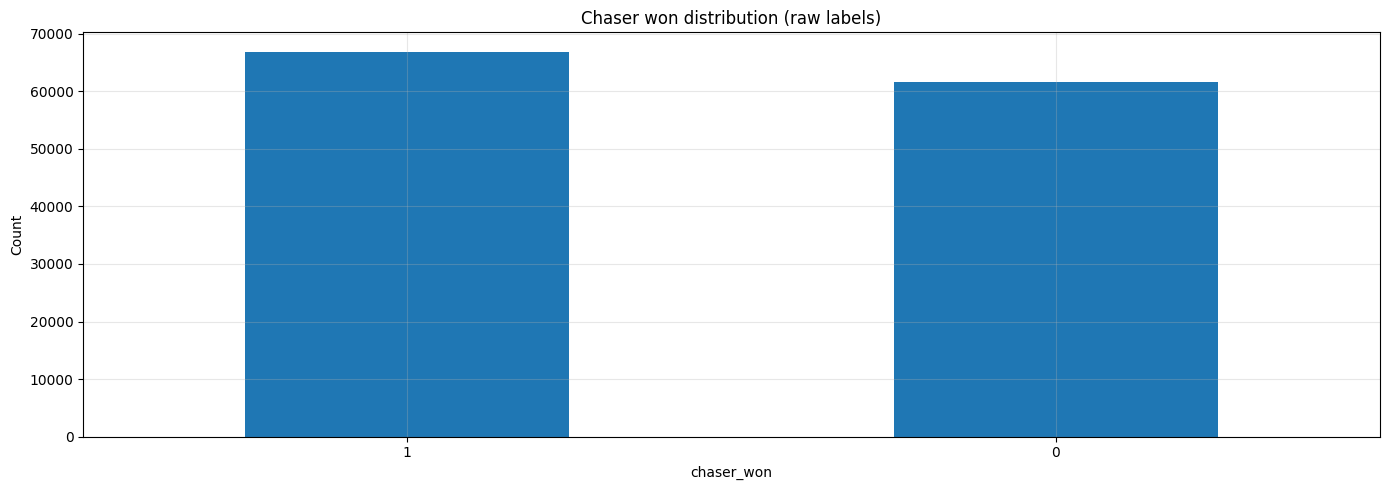

In [3]:
# Define the problem region: 6+ wickets down, needing 60+ runs off ≤30 balls
tail = df[(df['wickets_fallen'] >= 6) & (df['runs_needed'] >= 60) & (df['balls_remaining'] <= 30)]
print(f'Tail states (6+wk, 60+rn, ≤30br): {len(tail):,}')
print(f'  Chaser win rate in tail: {tail["chaser_won"].mean():.4f}')
print(f'  Expected: ~0.01–0.02, NB03 model: ~0.05–0.07')
print()

# Specific scenario from the backlog
scenario = df[
    (df['wickets_fallen'] >= 6) &
    (df['runs_needed'] >= 75) & (df['runs_needed'] <= 90) &
    (df['balls_remaining'] >= 12) & (df['balls_remaining'] <= 24)
]
print(f'Backlog scenario (6+wk, 75-90rn, 12-24br): {len(scenario):,} samples')
print(f'  True win rate: {scenario["chaser_won"].mean():.4f}')

# Distribution of chaser_won
df['chaser_won'].value_counts().plot(kind='bar', title='Chaser won distribution (raw labels)')
plt.xlabel('chaser_won')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / 'label_distribution.png', dpi=150)
plt.show()

## Step 3: Features and normalisation

Identical to NB03 — same 6 features, same z-score normalisation.

In [4]:
train_df = df.copy()

# Drop invalid end-of-match rows (balls_remaining <= 0 causes rrr div-by-zero or inf)
before = len(train_df)
train_df = train_df[train_df['balls_remaining'] > 0].copy()
print(f'Dropped {before - len(train_df)} rows with balls_remaining <= 0')

train_df['rrr']              = train_df['runs_needed'] / train_df['balls_remaining']
train_df['balls_fraction']   = train_df['balls_remaining'] / train_df['total_balls']
train_df['wickets_fraction'] = train_df['wickets_fallen'] / 10.0

# Clip rrr to [0, 6] — 6 runs/ball is extreme but physically possible; anything above is noise
train_df['rrr'] = train_df['rrr'].clip(0, 6)

FEATURE_COLS = ['runs_needed', 'balls_remaining', 'wickets_fallen',
                'rrr', 'balls_fraction', 'wickets_fraction']

X = train_df[FEATURE_COLS].values.astype(np.float32)
y = train_df['chaser_won'].values.astype(np.float32)

# Final sanity check
assert np.isfinite(X).all(), 'Still have NaN/inf in features!'
print(f'Feature ranges after cleaning:')
for i, col in enumerate(FEATURE_COLS):
    print(f'  {col}: [{X[:, i].min():.2f}, {X[:, i].max():.2f}]')

X_mean = X.mean(axis=0)
X_std  = X.std(axis=0) + 1e-8
X_norm = (X - X_mean) / X_std

print(f'\nX_norm range: [{X_norm.min():.2f}, {X_norm.max():.2f}]')
print(f'Samples: {len(X):,}  |  Positive rate: {y.mean():.3f}')
print('Feature means:', dict(zip(FEATURE_COLS, X_mean.round(2))))
print('Feature stds: ', dict(zip(FEATURE_COLS, X_std.round(2))))

Dropped 488 rows with balls_remaining <= 0
Feature ranges after cleaning:
  runs_needed: [-15.00, 287.00]
  balls_remaining: [1.00, 120.00]
  wickets_fallen: [0.00, 10.00]
  rrr: [0.00, 6.00]
  balls_fraction: [0.01, 0.99]
  wickets_fraction: [0.00, 1.00]

X_norm range: [-2.16, 4.68]
Samples: 128,023  |  Positive rate: 0.522
Feature means: {'runs_needed': 95.51, 'balls_remaining': 62.62, 'wickets_fallen': 2.47, 'rrr': 1.7, 'balls_fraction': 0.53, 'wickets_fraction': 0.25}
Feature stds:  {'runs_needed': 51.21, 'balls_remaining': 33.02, 'wickets_fallen': 2.14, 'rrr': 0.92, 'balls_fraction': 0.28, 'wickets_fraction': 0.21}


## Step 4: Model — same architecture as NB03, loss changed to BCE

In [5]:
class WinProbNet(nn.Module):
    def __init__(self, input_dim=6, hidden_dims=[64, 32, 16]):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(0.1)]
            prev = h
        layers += [nn.Linear(prev, 1)]  # no Sigmoid — BCEWithLogitsLoss expects raw logits
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

model_bce = WinProbNet()
print(model_bce)
print(f'\nTotal parameters: {sum(p.numel() for p in model_bce.parameters())}')

WinProbNet(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=16, out_features=1, bias=True)
  )
)

Total parameters: 3073


## Step 5: Train with BCE

Epoch  10/50 — train BCE: 0.43174  val BCE: 0.42527
Epoch  20/50 — train BCE: 0.42982  val BCE: 0.42306
Epoch  30/50 — train BCE: 0.42809  val BCE: 0.42156
Epoch  40/50 — train BCE: 0.42722  val BCE: 0.42032
Epoch  50/50 — train BCE: 0.42579  val BCE: 0.41983


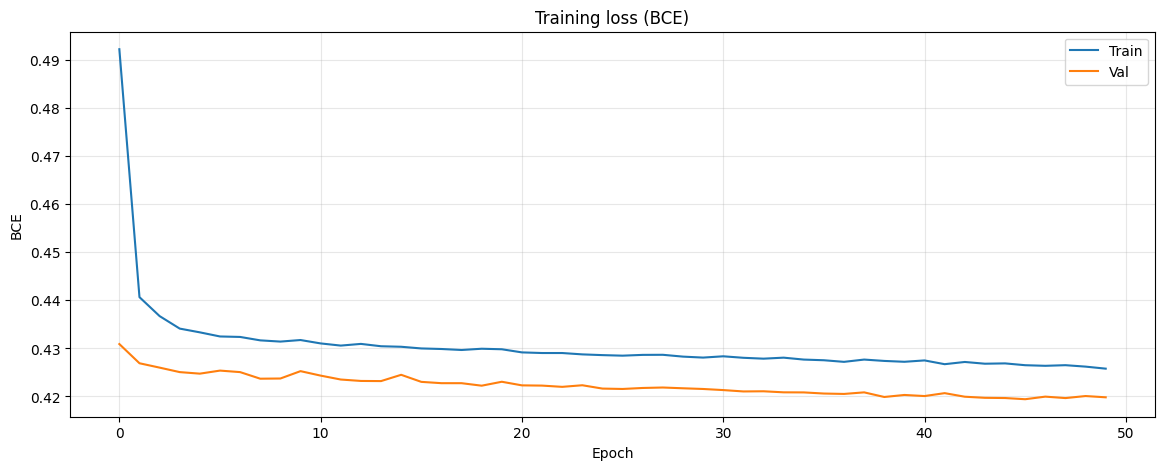

In [6]:
X_tensor = torch.tensor(X_norm)
y_tensor = torch.tensor(y)

dataset  = TensorDataset(X_tensor, y_tensor)
n_val    = int(0.15 * len(dataset))
n_train  = len(dataset) - n_val
train_ds, val_ds = random_split(dataset, [n_train, n_val])

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=512)

optimizer = torch.optim.Adam(model_bce.parameters(), lr=1e-3)
loss_fn   = nn.BCEWithLogitsLoss()  # fuses sigmoid+BCE — numerically stable, no boundary issues

EPOCHS = 50
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model_bce.train()
    batch_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model_bce(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))

    model_bce.eval()
    with torch.no_grad():
        val_loss = np.mean([loss_fn(model_bce(xb), yb).item() for xb, yb in val_loader])
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} — train BCE: {train_losses[-1]:.5f}  val BCE: {val_losses[-1]:.5f}')

plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Val')
plt.title('Training loss (BCE)')
plt.xlabel('Epoch')
plt.ylabel('BCE')
plt.legend()
plt.savefig(FIG_DIR / 'training_loss.png', dpi=150)
plt.show()

## Step 6: Load NB03 MSE model for comparison

In [14]:
class WinProbNetWithSigmoid(nn.Module):
    """NB03 architecture — Sigmoid included, outputs probabilities directly."""
    def __init__(self, input_dim=6, hidden_dims=[64, 32, 16]):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(0.1)]
            prev = h
        layers += [nn.Linear(prev, 1), nn.Sigmoid()]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


ckpt_nb03 = torch.load(MODELS_DIR / 'win_prob_nn.pt', weights_only=False)

model_mse = WinProbNetWithSigmoid(
    input_dim=ckpt_nb03['input_dim'],
    hidden_dims=ckpt_nb03['hidden_dims'],
)
model_mse.load_state_dict(ckpt_nb03['model_state_dict'])
model_mse.eval()

mse_mean = ckpt_nb03['X_mean']
mse_std  = ckpt_nb03['X_std']

print('NB03 (MSE) model loaded — with Sigmoid.')


def predict_bce(features_raw: np.ndarray) -> np.ndarray:
    """BCE model: outputs logits → apply sigmoid manually."""
    x = (features_raw - X_mean) / X_std
    with torch.no_grad():
        logits = model_bce(torch.tensor(x, dtype=torch.float32))
        return torch.sigmoid(logits).numpy()


def predict_mse(features_raw: np.ndarray) -> np.ndarray:
    """MSE model: Sigmoid is inside the model, outputs probabilities directly."""
    x = (features_raw - mse_mean) / mse_std
    with torch.no_grad():
        return model_mse(torch.tensor(x, dtype=torch.float32)).numpy()

NB03 (MSE) model loaded — with Sigmoid.


## Step 7: Tail calibration — the M2 scenario

Probe both models at states that triggered the M2 bug report.

In [15]:
def make_features_mse(runs_needed, balls_remaining, wickets_fallen, total_balls=120):
    """Features matching NB03 training: rrr = rn / (br + 1)"""
    rrr = runs_needed / (balls_remaining + 1)
    bf  = balls_remaining / total_balls
    wf  = wickets_fallen / 10.0
    return np.array([[runs_needed, balls_remaining, wickets_fallen, rrr, bf, wf]], dtype=np.float32)

def make_features_bce(runs_needed, balls_remaining, wickets_fallen, total_balls=120):
    """Features matching NB09 training: rrr = rn / br clipped, br >= 1"""
    rrr = float(np.clip(runs_needed / max(balls_remaining, 1), 0, 6))
    bf  = balls_remaining / total_balls
    wf  = wickets_fallen / 10.0
    return np.array([[runs_needed, balls_remaining, wickets_fallen, rrr, bf, wf]], dtype=np.float32)


scenarios = [
    # (label, runs_needed, balls_remaining, wickets_fallen)
    ('6wk, 80rn, 18br  [M2 bug]',    80, 18, 6),
    ('6wk, 100rn, 12br [hopeless]', 100, 12, 6),
    ('7wk, 60rn, 12br  [desperate]', 60, 12, 7),
    ('3wk, 40rn, 30br  [mid-chase]', 40, 30, 3),
    ('0wk, 1rn,  12br  [near-win]',   1, 12, 0),
    ('0wk, 60rn, 60br  [50-50]',     60, 60, 0),
]

print(f'{"Scenario":<35} {"True rate":>10} {"NB03 (MSE)":>12} {"NB09 (BCE)":>12}')
print('-' * 72)
for label, rn, br, wk in scenarios:
    p_mse = float(predict_mse(make_features_mse(rn, br, wk))[0])
    p_bce = float(predict_bce(make_features_bce(rn, br, wk))[0])

    mask = (
        (df['runs_needed'].between(rn - 5, rn + 5)) &
        (df['balls_remaining'].between(br - 3, br + 3)) &
        (df['wickets_fallen'] == wk)
    )
    emp_rate = df[mask]['chaser_won'].mean() if mask.sum() >= 5 else float('nan')

    print(f'{label:<35} {emp_rate:>10.4f} {p_mse:>12.4f} {p_bce:>12.4f}')

Scenario                             True rate   NB03 (MSE)   NB09 (BCE)
------------------------------------------------------------------------
6wk, 80rn, 18br  [M2 bug]               0.0000       0.0005       0.0001
6wk, 100rn, 12br [hopeless]                nan       0.0000       0.0000
7wk, 60rn, 12br  [desperate]            0.0000       0.0005       0.0000
3wk, 40rn, 30br  [mid-chase]            0.8677       0.8559       0.8594
0wk, 1rn,  12br  [near-win]             1.0000       0.9892       0.9999
0wk, 60rn, 60br  [50-50]                1.0000       0.9851       0.9781


## Step 8: Win prob curves on validation matches

Check that BCE model tracks match drama similarly to MSE — signal timing should be unchanged.

C:\Users\hp\AppData\Local\Temp\ipykernel_24832\771146448.py:41: RuntimeWarning: divide by zero encountered in divide
  rn / (br + 1),          # rrr with +1 offset as in NB03


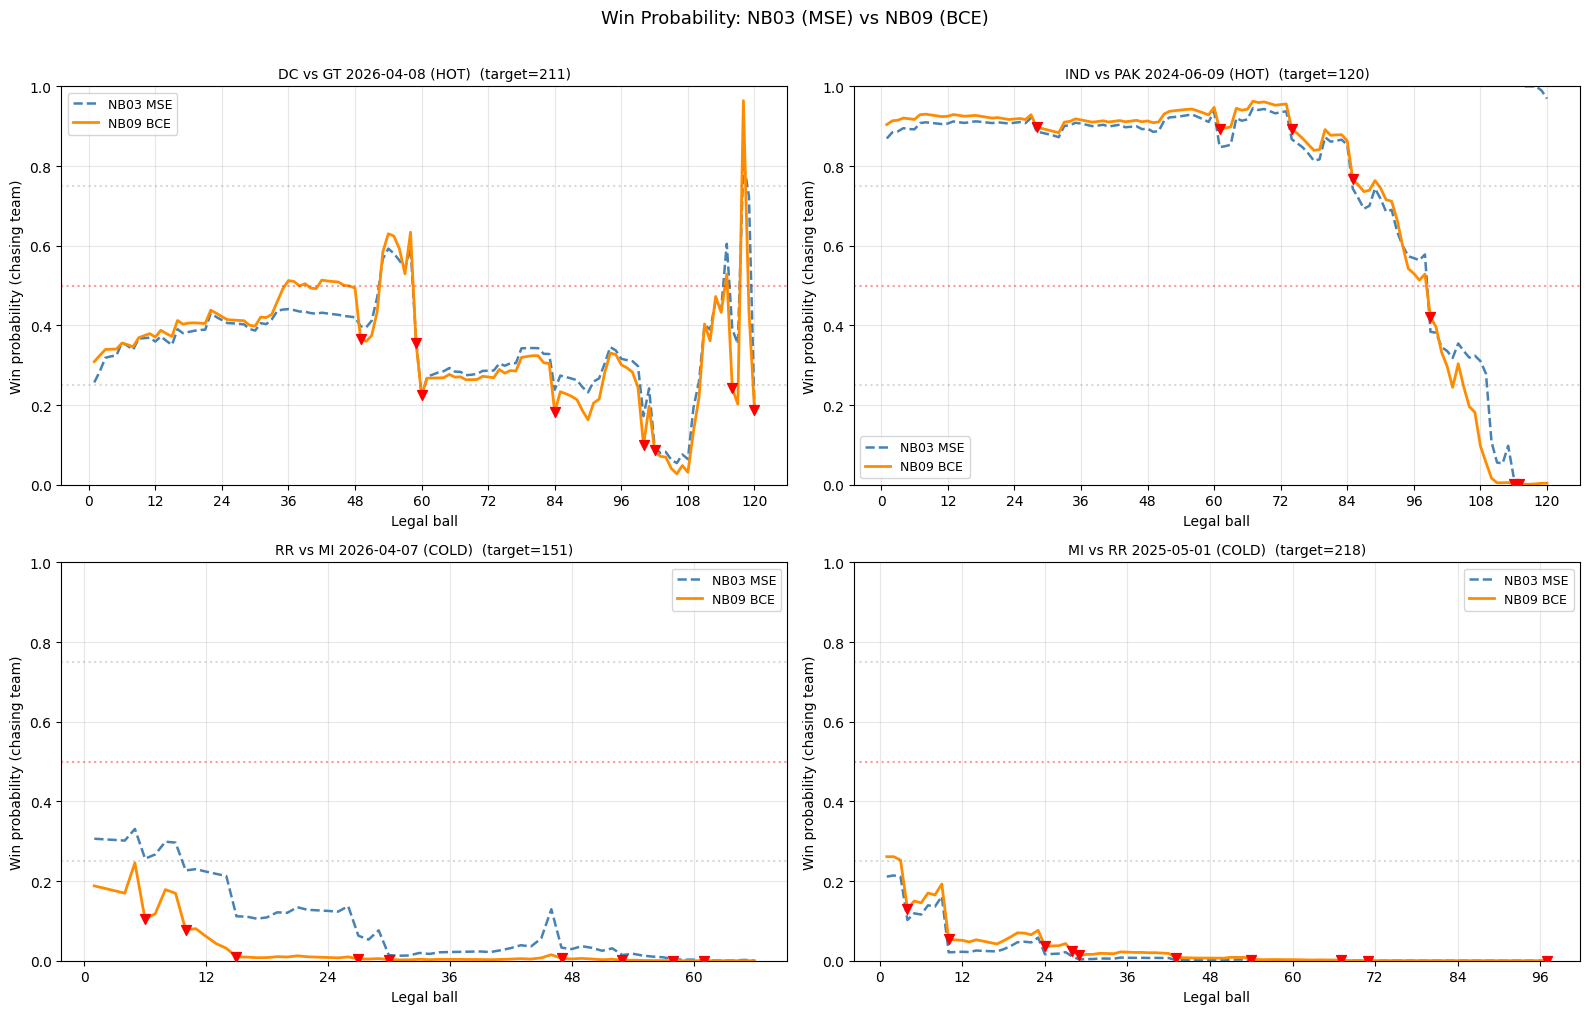

In [16]:
def build_chase(path):
    with open(path) as f:
        d = json.load(f)

    inn1, inn2 = d['innings'][0], d['innings'][1]
    inn1_score = sum(b['runs']['total'] for ov in inn1['overs'] for b in ov['deliveries'])
    target = inn1_score + 1
    total_balls = sum(
        1 for ov in inn1['overs'] for b in ov['deliveries']
        if 'wides' not in b.get('extras', {}) and 'noballs' not in b.get('extras', {})
    )

    rows = []
    score, wickets, legal_ball = 0, 0, 0
    for ov in inn2['overs']:
        for b in ov['deliveries']:
            ext = list(b.get('extras', {}).keys())
            is_legal = 'wides' not in ext and 'noballs' not in ext
            score += b['runs']['total']
            if 'wickets' in b:
                wickets += len(b['wickets'])
            if is_legal:
                legal_ball += 1
                rows.append({
                    'legal_ball': legal_ball, 'score': score,
                    'wickets_fallen': wickets, 'is_wicket': 'wickets' in b,
                    'runs_needed': target - score,
                    'balls_remaining': total_balls - legal_ball,
                    'total_balls': total_balls,
                })

    chase = pd.DataFrame(rows)
    rn = chase['runs_needed'].values.astype(np.float32)
    br = chase['balls_remaining'].values.astype(np.float32)
    wk = chase['wickets_fallen'].values.astype(np.float32)
    tb = chase['total_balls'].values.astype(np.float32)

    # MSE model: trained with rrr = rn / (br + 1)  — match NB03 training exactly
    feat_mse = np.column_stack([
        rn, br, wk,
        rn / (br + 1),          # rrr with +1 offset as in NB03
        br / tb,                 # balls_fraction
        wk / 10.0,               # wickets_fraction
    ]).astype(np.float32)

    # BCE model: trained with rrr = rn / br, clipped — match NB09 step 3 exactly
    feat_bce = np.column_stack([
        rn, br, wk,
        np.clip(rn / np.maximum(br, 1), 0, 6),   # rrr clipped, br floored at 1
        br / tb,
        wk / 10.0,
    ]).astype(np.float32)

    chase['wp_mse'] = predict_mse(feat_mse)
    chase['wp_bce'] = predict_bce(feat_bce)
    return chase, target


match_files = {
    'DC vs GT 2026-04-08 (HOT)':   'dc_vs_gt_2026-04-08.json',
    'IND vs PAK 2024-06-09 (HOT)': 'ind_vs_pak_2024-06-09.json',
    'RR vs MI 2026-04-07 (COLD)':  'rr_vs_mi_2026-04-07.json',
    'MI vs RR 2025-05-01 (COLD)':  'mi_vs_rr_2025-05-01.json',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (label, fname) in zip(axes, match_files.items()):
    try:
        chase, target = build_chase(DATA + fname)
    except FileNotFoundError:
        ax.set_title(f'{label}\n(file not found)')
        continue

    ax.plot(chase['legal_ball'], chase['wp_mse'], label='NB03 MSE',
            color='steelblue', linewidth=1.8, linestyle='--')
    ax.plot(chase['legal_ball'], chase['wp_bce'], label='NB09 BCE',
            color='darkorange', linewidth=2)
    ax.axhline(0.5, color='red', linestyle=':', alpha=0.4)
    ax.axhline(0.25, color='grey', linestyle=':', alpha=0.3)
    ax.axhline(0.75, color='grey', linestyle=':', alpha=0.3)

    wk_balls = chase[chase['is_wicket']]
    ax.scatter(wk_balls['legal_ball'], wk_balls['wp_bce'], color='red', zorder=5, s=50, marker='v')

    ax.set_title(f'{label}  (target={target})', fontsize=10)
    ax.set_xlabel('Legal ball')
    ax.set_ylabel('Win probability (chasing team)')
    ax.set_ylim(0, 1)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
    ax.legend(fontsize=9)

plt.suptitle('Win Probability: NB03 (MSE) vs NB09 (BCE)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'win_prob_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9: Calibration plot (reliability diagram)

Bin predictions into deciles and compare predicted probability vs actual win rate. A well-calibrated model lies on the diagonal.

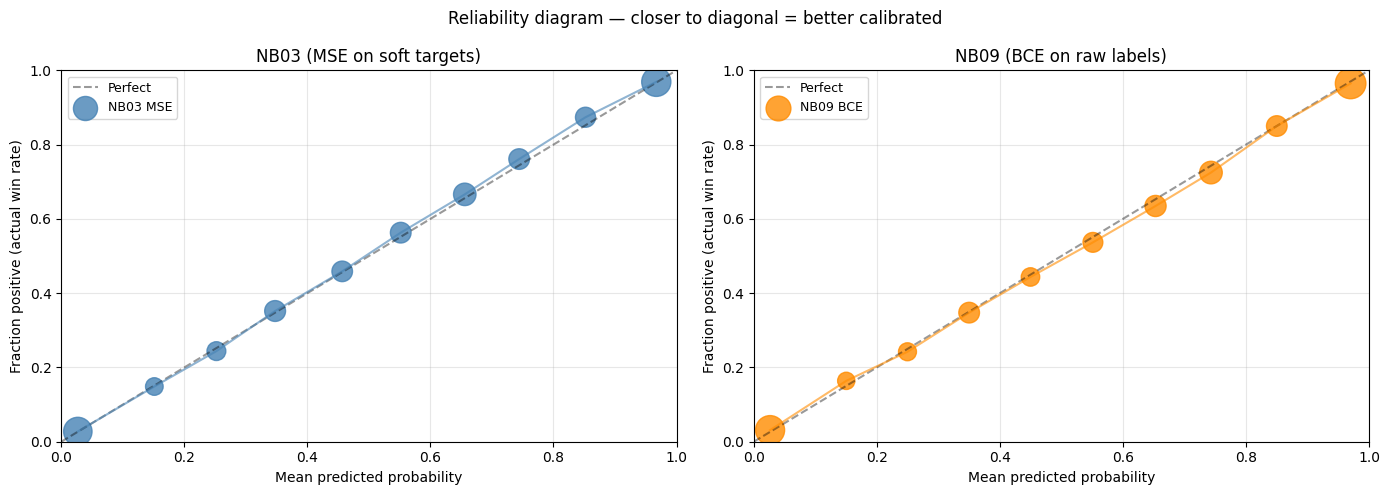


Tail calibration (p < 0.10):
  NB03 MSE: 20,900 samples — mean pred=0.0269, actual win rate=0.0276
  NB09 BCE: 21,890 samples — mean pred=0.0265, actual win rate=0.0312


In [17]:
X_all = train_df[FEATURE_COLS].values.astype(np.float32)
y_all = train_df['chaser_won'].values

p_mse_all = predict_mse(X_all)
p_bce_all = predict_bce(X_all)

def reliability_diagram(ax, y_true, y_pred, label, color):
    bins = np.linspace(0, 1, 11)
    bin_idx = np.digitize(y_pred, bins) - 1
    bin_idx = np.clip(bin_idx, 0, 9)

    mean_pred, mean_true, counts = [], [], []
    for b in range(10):
        mask = bin_idx == b
        if mask.sum() >= 10:
            mean_pred.append(y_pred[mask].mean())
            mean_true.append(y_true[mask].mean())
            counts.append(mask.sum())

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect')
    ax.scatter(mean_pred, mean_true, s=[c / 50 for c in counts],
               color=color, alpha=0.8, label=label)
    ax.plot(mean_pred, mean_true, color=color, alpha=0.6)
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction positive (actual win rate)')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
reliability_diagram(axes[0], y_all, p_mse_all, 'NB03 MSE', 'steelblue')
axes[0].set_title('NB03 (MSE on soft targets)')
reliability_diagram(axes[1], y_all, p_bce_all, 'NB09 BCE', 'darkorange')
axes[1].set_title('NB09 (BCE on raw labels)')

plt.suptitle('Reliability diagram — closer to diagonal = better calibrated', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'reliability_diagram.png', dpi=150)
plt.show()

# Tail-specific calibration
print('\nTail calibration (p < 0.10):')
for label, preds in [('NB03 MSE', p_mse_all), ('NB09 BCE', p_bce_all)]:
    mask = preds < 0.10
    if mask.sum() > 0:
        print(f'  {label}: {mask.sum():,} samples — mean pred={preds[mask].mean():.4f}, actual win rate={y_all[mask].mean():.4f}')

## Step 10: Decision — save BCE model?

Save only if:
1. Tail calibration improved (BCE < MSE at p < 0.10)
2. Mid-range curves look similar on validation matches
3. No new false positives on COLD matches

In [19]:
SAVE_BCE = True  # set to True after reviewing results above

if SAVE_BCE:
    FEATURE_COLS_SAVE = FEATURE_COLS
    ckpt = {
        'input_dim': len(FEATURE_COLS_SAVE),
        'hidden_dims': [64, 32, 16],
        'model_state_dict': model_bce.state_dict(),
        'feature_cols': FEATURE_COLS_SAVE,
        'X_mean': X_mean,
        'X_std': X_std,
        'training': 'BCE on raw chaser_won labels (NB09)',
    }
    out_path = MODELS_DIR / 'win_prob_nn_bce.pt'
    torch.save(ckpt, out_path)
    print(f'Saved BCE model to {out_path}')
    print('To swap into production: rename to win_prob_nn.pt (keep backup of original)')
else:
    print('SAVE_BCE=False — set to True after confirming results are better')

Saved BCE model to ..\models\win_prob_nn_bce.pt
To swap into production: rename to win_prob_nn.pt (keep backup of original)
